Donor Engagement Predictor

In [78]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report
)

import matplotlib.pyplot as plt
import seaborn as sns

print("Libraries Imported Successfully!")

Libraries Imported Successfully!


In [79]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report
)

import matplotlib.pyplot as plt
import seaborn as sns

print("Libraries Imported Successfully!")

Libraries Imported Successfully!


In [80]:
df = pd.read_csv("/content/dataset/marketing_campaign.csv", sep='\t')

print("Dataset Shape:", df.shape)
df.head()

Dataset Shape: (2240, 29)


,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
0,5524,1957,Graduation,Single,58138.0,0,0,04-09-2012,58,635,...,7,0,0,0,0,0,0,3,11,1
1,2174,1954,Graduation,Single,46344.0,1,1,08-03-2014,38,11,...,5,0,0,0,0,0,0,3,11,0
2,4141,1965,Graduation,Together,71613.0,0,0,21-08-2013,26,426,...,4,0,0,0,0,0,0,3,11,0
3,6182,1984,Graduation,Together,26646.0,1,0,10-02-2014,26,11,...,6,0,0,0,0,0,0,3,11,0
4,5324,1981,PhD,Married,58293.0,1,0,19-01-2014,94,173,...,5,0,0,0,0,0,0,3,11,0


Data Cleaning and Initial Exploration


In [81]:
df.info()

print("\nMissing values per column:")
print(df.isnull().sum()[df.isnull().sum() > 0])

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2240 entries, 0 to 2239
Data columns (total 29 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   ID                   2240 non-null   int64  
 1   Year_Birth           2240 non-null   int64  
 2   Education            2240 non-null   object 
 3   Marital_Status       2240 non-null   object 
 4   Income               2216 non-null   float64
 5   Kidhome              2240 non-null   int64  
 6   Teenhome             2240 non-null   int64  
 7   Dt_Customer          2240 non-null   object 
 8   Recency              2240 non-null   int64  
 9   MntWines             2240 non-null   int64  
 10  MntFruits            2240 non-null   int64  
 11  MntMeatProducts      2240 non-null   int64  
 12  MntFishProducts      2240 non-null   int64  
 13  MntSweetProducts     2240 non-null   int64  
 14  MntGoldProds         2240 non-null   int64  
 15  NumDealsPurchases    2240 non-null   i

Handling Missing Values and Dropping Unnecessary Columns

In [82]:
df['Income'].fillna(df['Income'].median(), inplace=True)
df.drop(columns=['ID', 'Z_CostContact', 'Z_Revenue'], inplace=True)
df['Dt_Customer'] = pd.to_datetime(df['Dt_Customer'], format='%d-%m-%Y')

print("Missing values after imputation:")
print(df.isnull().sum()[df.isnull().sum() > 0])
print("\nDataFrame shape after dropping columns:", df.shape)
print("\nUpdated DataFrame Info:")
df.info()

Missing values after imputation:
Series([], dtype: int64)

DataFrame shape after dropping columns: (2240, 26)

Updated DataFrame Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2240 entries, 0 to 2239
Data columns (total 26 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   Year_Birth           2240 non-null   int64         
 1   Education            2240 non-null   object        
 2   Marital_Status       2240 non-null   object        
 3   Income               2240 non-null   float64       
 4   Kidhome              2240 non-null   int64         
 5   Teenhome             2240 non-null   int64         
 6   Dt_Customer          2240 non-null   datetime64[ns]
 7   Recency              2240 non-null   int64         
 8   MntWines             2240 non-null   int64         
 9   MntFruits            2240 non-null   int64         
 10  MntMeatProducts      2240 non-null   int64         
 11  MntFishProdu

/tmp/ipykernel_2903/393598481.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Income'].fillna(df['Income'].median(), inplace=True)


Feature Engineering

In [83]:
df['Will_Donate_Next'] = df['Response']

df['Age'] = 2024 - df['Year_Birth'] # Assuming current year is 2024

df['Family_Size'] = df['Kidhome'] + df['Teenhome']
df['Family_Size'] = df.apply(lambda row: row['Family_Size'] + 1 if row['Marital_Status'] in ['Single', 'Divorced', 'Widowed', 'Alone'] else row['Family_Size'] + 2, axis=1) # Add 1 for single parent, 2 for couple (approximated, as we don't have exact partner info beyond marital status)

latest_date = df['Dt_Customer'].max()
df['Days_Since_Enrollment'] = (latest_date - df['Dt_Customer']).dt.days

df['Total_Spending'] = df['MntWines'] + df['MntFruits'] + df['MntMeatProducts'] + \
                       df['MntFishProducts'] + df['MntSweetProducts'] + df['MntGoldProds']

df['Total_Purchases'] = df['NumDealsPurchases'] + df['NumWebPurchases'] + \
                        df['NumCatalogPurchases'] + df['NumStorePurchases']

df['Accepted_Cmp_Count'] = df[['AcceptedCmp1', 'AcceptedCmp2', 'AcceptedCmp3', 'AcceptedCmp4', 'AcceptedCmp5']].sum(axis=1)

df.drop(columns=[
    'Year_Birth', 'Kidhome', 'Teenhome', 'Dt_Customer',
    'MntWines', 'MntFruits', 'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts', 'MntGoldProds',
    'NumDealsPurchases', 'NumWebPurchases', 'NumCatalogPurchases', 'NumStorePurchases',
    'AcceptedCmp1', 'AcceptedCmp2', 'AcceptedCmp3', 'AcceptedCmp4', 'AcceptedCmp5', 'Response'
], inplace=True)

print("DataFrame shape after feature engineering:", df.shape)
print("\nDataFrame Info after feature engineering:")
df.info()

DataFrame shape after feature engineering: (2240, 13)

DataFrame Info after feature engineering:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2240 entries, 0 to 2239
Data columns (total 13 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Education              2240 non-null   object 
 1   Marital_Status         2240 non-null   object 
 2   Income                 2240 non-null   float64
 3   Recency                2240 non-null   int64  
 4   NumWebVisitsMonth      2240 non-null   int64  
 5   Complain               2240 non-null   int64  
 6   Will_Donate_Next       2240 non-null   int64  
 7   Age                    2240 non-null   int64  
 8   Family_Size            2240 non-null   int64  
 9   Days_Since_Enrollment  2240 non-null   int64  
 10  Total_Spending         2240 non-null   int64  
 11  Total_Purchases        2240 non-null   int64  
 12  Accepted_Cmp_Count     2240 non-null   int64  
dtypes: float64(

In [84]:
df = pd.get_dummies(df, columns=['Education', 'Marital_Status'], drop_first=True)

print("DataFrame shape after one-hot encoding:", df.shape)
print("\nDataFrame Info after one-hot encoding:")
df.info()

DataFrame shape after one-hot encoding: (2240, 22)

DataFrame Info after one-hot encoding:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2240 entries, 0 to 2239
Data columns (total 22 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Income                   2240 non-null   float64
 1   Recency                  2240 non-null   int64  
 2   NumWebVisitsMonth        2240 non-null   int64  
 3   Complain                 2240 non-null   int64  
 4   Will_Donate_Next         2240 non-null   int64  
 5   Age                      2240 non-null   int64  
 6   Family_Size              2240 non-null   int64  
 7   Days_Since_Enrollment    2240 non-null   int64  
 8   Total_Spending           2240 non-null   int64  
 9   Total_Purchases          2240 non-null   int64  
 10  Accepted_Cmp_Count       2240 non-null   int64  
 11  Education_Basic          2240 non-null   bool   
 12  Education_Graduation     2240 non-null   

In [85]:
X = df.drop('Will_Donate_Next', axis=1)
y = df['Will_Donate_Next']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

print("\nTarget variable distribution in training set:")
print(y_train.value_counts(normalize=True))
print("\nTarget variable distribution in testing set:")
print(y_test.value_counts(normalize=True))

X_train shape: (1792, 21)
X_test shape: (448, 21)
y_train shape: (1792,)
y_test shape: (448,)

Target variable distribution in training set:
Will_Donate_Next
0    0.851004
1    0.148996
Name: proportion, dtype: float64

Target variable distribution in testing set:
Will_Donate_Next
0    0.850446
1    0.149554
Name: proportion, dtype: float64


Machine Learning Models

1. Logistic Regression

In [86]:
log_reg_model = LogisticRegression(random_state=42, solver='liblinear')
log_reg_model.fit(X_train, y_train)

y_pred_lr = log_reg_model.predict(X_test)

print("Logistic Regression Model Performance:")
print(f"Accuracy: {accuracy_score(y_test, y_pred_lr):.4f}")
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred_lr))
print("\nClassification Report:\n", classification_report(y_test, y_pred_lr))

Logistic Regression Model Performance:
Accuracy: 0.8616

Confusion Matrix:
 [[372   9]
 [ 53  14]]

Classification Report:
               precision    recall  f1-score   support

           0       0.88      0.98      0.92       381
           1       0.61      0.21      0.31        67

    accuracy                           0.86       448
   macro avg       0.74      0.59      0.62       448
weighted avg       0.84      0.86      0.83       448



2. Decision Tree Classifier

In [87]:
dt_model = DecisionTreeClassifier(random_state=42)
dt_model.fit(X_train, y_train)

y_pred_dt = dt_model.predict(X_test)

print("Decision Tree Classifier Performance:")
print(f"Accuracy: {accuracy_score(y_test, y_pred_dt):.4f}")
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred_dt))
print("\nClassification Report:\n", classification_report(y_test, y_pred_dt))

Decision Tree Classifier Performance:
Accuracy: 0.8549

Confusion Matrix:
 [[351  30]
 [ 35  32]]

Classification Report:
               precision    recall  f1-score   support

           0       0.91      0.92      0.92       381
           1       0.52      0.48      0.50        67

    accuracy                           0.85       448
   macro avg       0.71      0.70      0.71       448
weighted avg       0.85      0.85      0.85       448



3. Random Forest Classifier

In [88]:
rf_model = RandomForestClassifier(random_state=42)
rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)

print("Random Forest Classifier Performance:")
print(f"Accuracy: {accuracy_score(y_test, y_pred_rf):.4f}")
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred_rf))
print("\nClassification Report:\n", classification_report(y_test, y_pred_rf))

Random Forest Classifier Performance:
Accuracy: 0.8906

Confusion Matrix:
 [[375   6]
 [ 43  24]]

Classification Report:
               precision    recall  f1-score   support

           0       0.90      0.98      0.94       381
           1       0.80      0.36      0.49        67

    accuracy                           0.89       448
   macro avg       0.85      0.67      0.72       448
weighted avg       0.88      0.89      0.87       448



 Best Model & Feature Importance

Based on the evaluation metrics, the Random Forest Classifier performed best.

Top 10 Feature Importances (Random Forest):
                  Feature  Importance
1                 Recency    0.130478
6   Days_Since_Enrollment    0.126894
7          Total_Spending    0.125814
9      Accepted_Cmp_Count    0.124170
0                  Income    0.120471
4                     Age    0.082142
8         Total_Purchases    0.069173
2       NumWebVisitsMonth    0.059047
5             Family_Size    0.052445
13          Education_PhD    0.016745


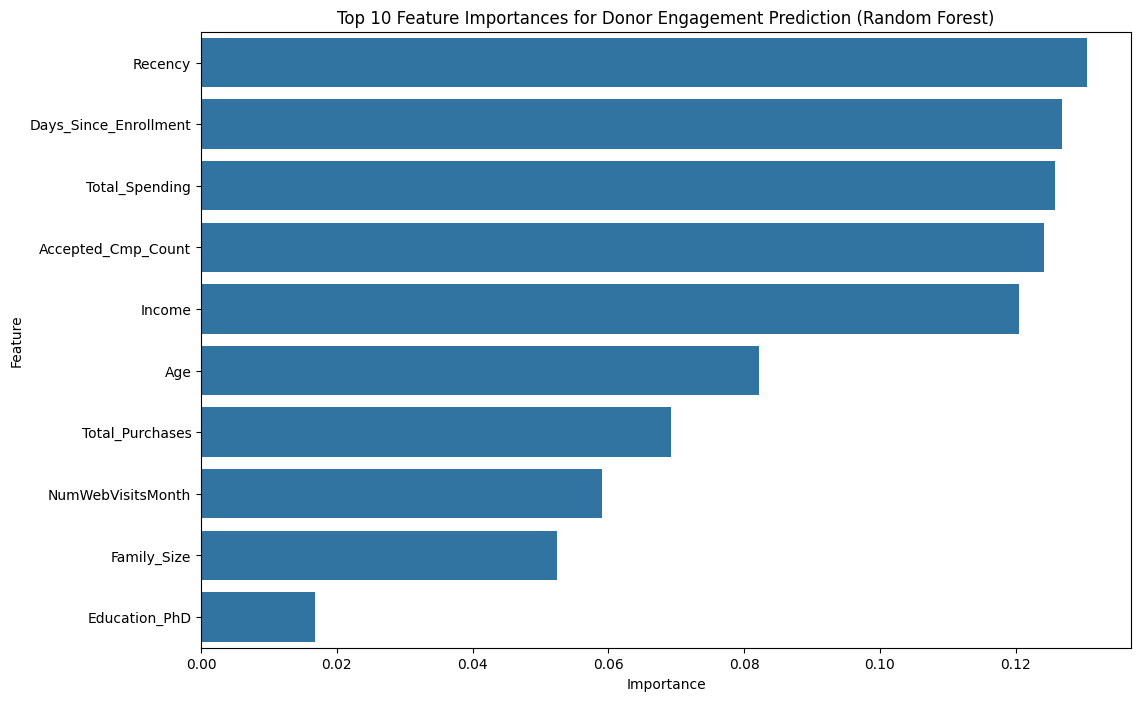

In [89]:
feature_importances = rf_model.feature_importances_

features_df = pd.DataFrame({
    'Feature': X.columns,
    'Importance': feature_importances
}).sort_values(by='Importance', ascending=False)

print("Top 10 Feature Importances (Random Forest):")
print(features_df.head(10))

plt.figure(figsize=(12, 8))
sns.barplot(x='Importance', y='Feature', data=features_df.head(10))
plt.title('Top 10 Feature Importances for Donor Engagement Prediction (Random Forest)')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.show()

Correlation Matrix of Top Features



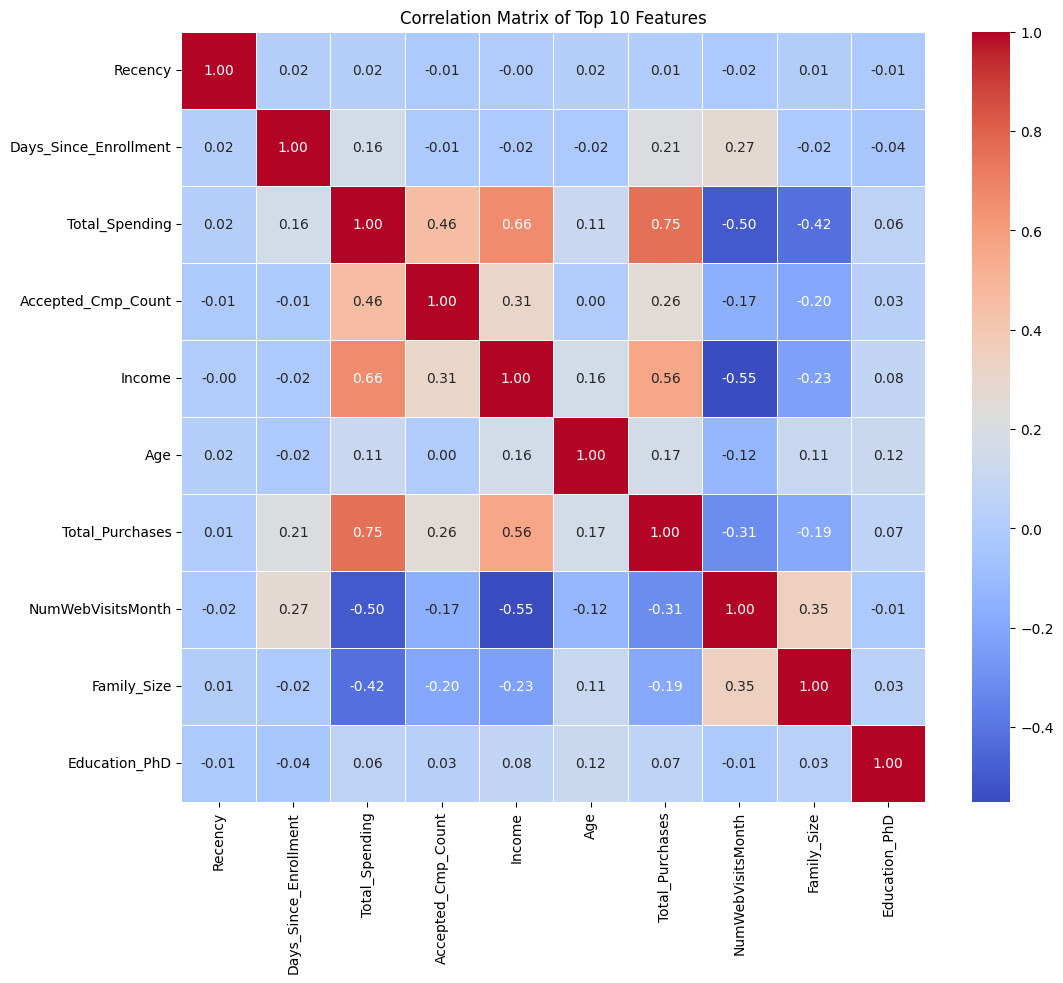

In [90]:
top_10_features = features_df['Feature'].head(10).tolist()

X_top_features = X[top_10_features]

correlation_matrix = X_top_features.corr()

plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title('Correlation Matrix of Top 10 Features')
plt.show()

### Correlation Matrix of Top Features

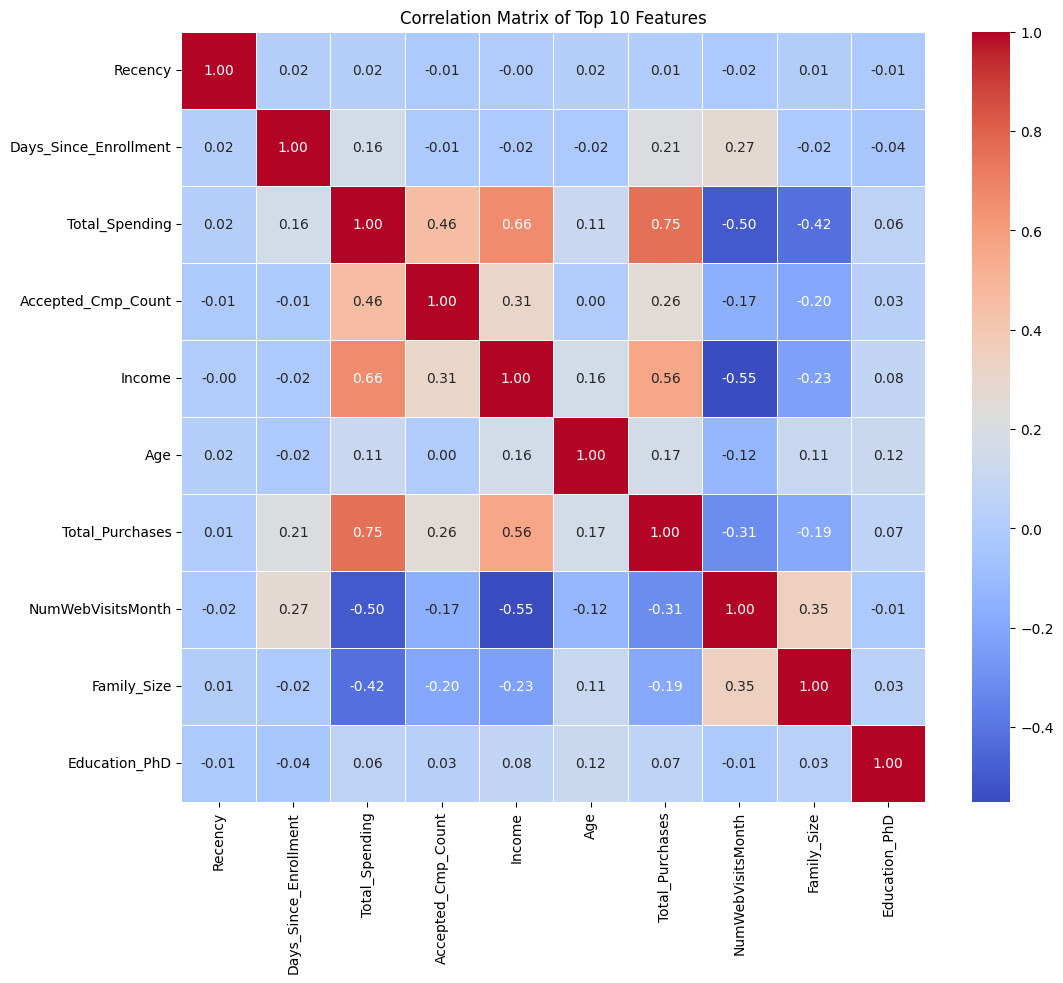

In [91]:
top_10_features = features_df['Feature'].head(10).tolist()

X_top_features = X[top_10_features]

correlation_matrix = X_top_features.corr()

plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title('Correlation Matrix of Top 10 Features')
plt.show()

### Feature Importance

Top 10 Feature Importances (Random Forest):
                  Feature  Importance
1                 Recency    0.130478
6   Days_Since_Enrollment    0.126894
7          Total_Spending    0.125814
9      Accepted_Cmp_Count    0.124170
0                  Income    0.120471
4                     Age    0.082142
8         Total_Purchases    0.069173
2       NumWebVisitsMonth    0.059047
5             Family_Size    0.052445
13          Education_PhD    0.016745


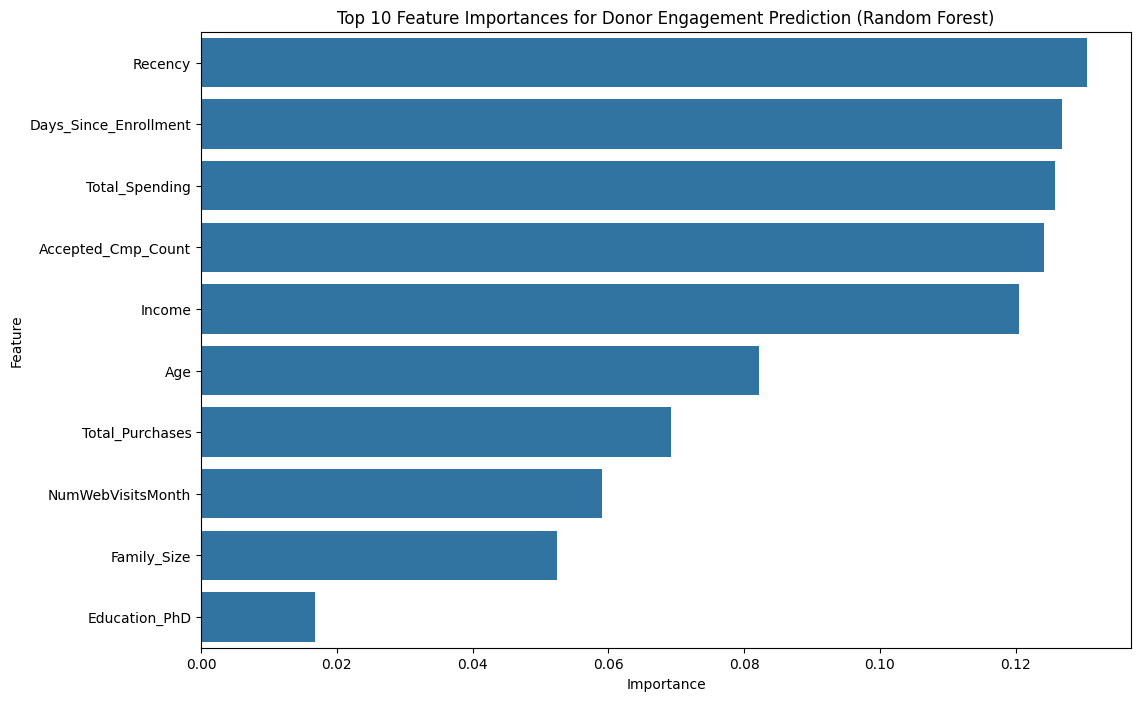

In [92]:
feature_importances = rf_model.feature_importances_

features_df = pd.DataFrame({
    'Feature': X.columns,
    'Importance': feature_importances
}).sort_values(by='Importance', ascending=False)

print("Top 10 Feature Importances (Random Forest):")
print(features_df.head(10))

plt.figure(figsize=(12, 8))
sns.barplot(x='Importance', y='Feature', data=features_df.head(10))
plt.title('Top 10 Feature Importances for Donor Engagement Prediction (Random Forest)')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.show()

### Model Comparison

/tmp/ipykernel_2903/3024248069.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=models, y=accuracies, palette='viridis')


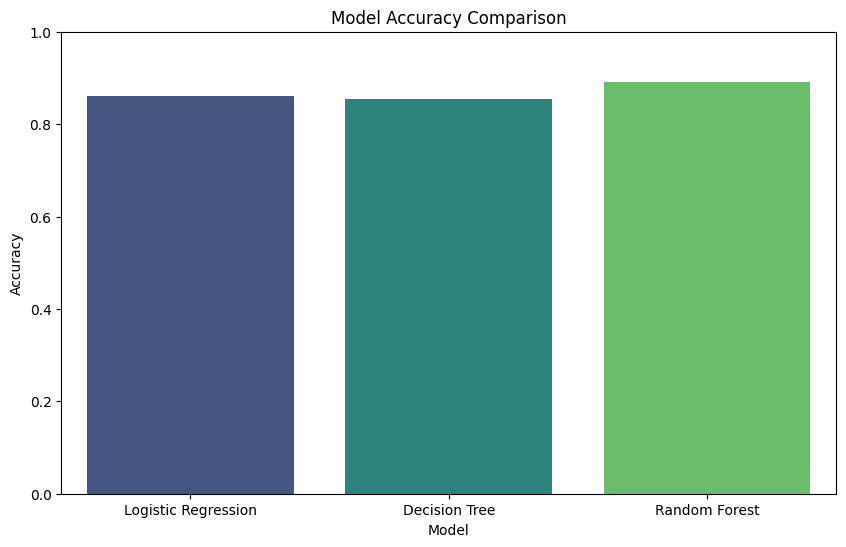

In [93]:
models = ['Logistic Regression', 'Decision Tree', 'Random Forest']
accuracies = [accuracy_score(y_test, y_pred_lr), accuracy_score(y_test, y_pred_dt), accuracy_score(y_test, y_pred_rf)]

plt.figure(figsize=(10, 6))
sns.barplot(x=models, y=accuracies, palette='viridis')
plt.title('Model Accuracy Comparison')
plt.xlabel('Model')
plt.ylabel('Accuracy')
plt.ylim(0, 1) # Accuracy is between 0 and 1
plt.show()

### Confusion Matrix for Random Forest Classifier

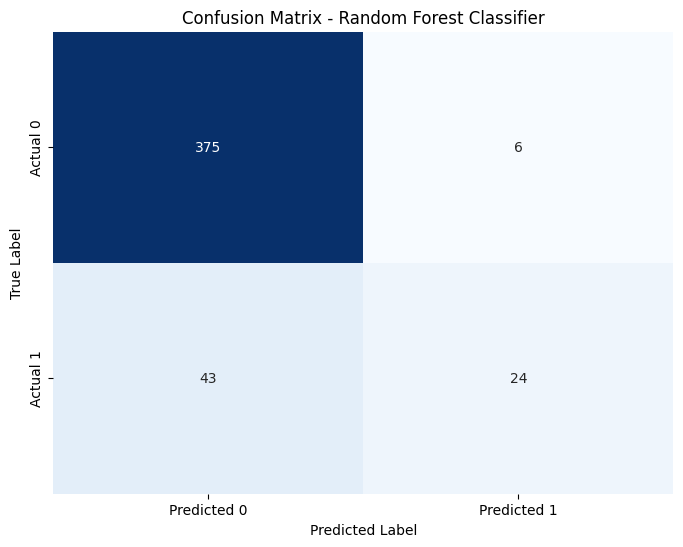

In [94]:
cm_rf = confusion_matrix(y_test, y_pred_rf)

plt.figure(figsize=(8, 6))
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Predicted 0', 'Predicted 1'],
            yticklabels=['Actual 0', 'Actual 1'])
plt.title('Confusion Matrix - Random Forest Classifier')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

### Confusion Matrix for Best Model (Random Forest Classifier)

The confusion matrix for the Random Forest Classifier, which was identified as the best model, is as follows:

```
[[375   6]
 [ 43  24]]
```

